# Notebook 02 — Prétraitement & Feature Engineering
**Projet :** Système Intelligent de Détection de Spam et de Phishing  
**Auteur :** Nghogué Taptué Franck Roddier — 5GI, ENSPY  
**Semaine :** 1 / 3  
**Entrée :** `data/emails_raw.csv` (produit par NB 01)  
**Sorties :** `data/emails_features.csv`, `data/tfidf_vectorizer.pkl`, `data/label_encoder.pkl`

---

## Objectifs
1. Nettoyer le texte brut (HTML, URLs, stopwords, lemmatisation)
2. Extraire des features textuelles (TF-IDF)
3. Extraire des features structurelles (URLs, domaines, headers)
4. Construire une matrice de features finale
5. Gérer le déséquilibre des classes (SMOTE + visualisation)
6. Séparer le dataset en train / validation / test
7. Sauvegarder tous les artefacts pour les notebooks suivants

## 0. Installation des dépendances

In [1]:
# Exécuter une seule fois
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn nltk tqdm joblib


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]


In [2]:
import re
import html
import string
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from urllib.parse import urlparse

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# NLTK
import nltk
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)
nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)
from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATA_DIR = Path('data')
CLASS_COLORS = {'ham': '#1D9E75', 'spam': '#D85A30', 'phishing': '#BA7517'}

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

print('Environnement prêt.')

Environnement prêt.


## 1. Chargement du dataset brut

In [3]:
raw_path = DATA_DIR / 'emails_raw.csv'

if not raw_path.exists():
    raise FileNotFoundError(
        'emails_raw.csv introuvable. Exécutez le Notebook 01 en premier.'
    )

df = pd.read_csv(raw_path)

print(f'Dataset chargé : {len(df):,} emails')
print(f'Colonnes : {list(df.columns)}')
print()
print(df['label'].value_counts())
print()
print('Aperçu :')
df.head(3)

Dataset chargé : 60 emails
Colonnes : ['text', 'label', 'source', 'word_count', 'char_count', 'url_count', 'exclamation', 'uppercase_ratio', 'has_html', 'has_ip_url', 'dollar_count']

label
ham         20
spam        20
phishing    20
Name: count, dtype: int64

Aperçu :


,text,label,source,word_count,char_count,url_count,exclamation,uppercase_ratio,has_html,has_ip_url,dollar_count
0,"Hi team, please find attached the quarterly re...",ham,synthetic,18,97,0,0,0.030928,False,False,0
1,Your monthly bank statement is now available i...,ham,synthetic,12,75,0,0,0.013333,False,False,0
2,"ROLEX replicas — undetectable. Same quality, 9...",spam,synthetic,11,77,0,2,0.090909,False,False,0


## 2. Nettoyage du texte

Le pipeline de nettoyage suit les recommandations §3.1 du cahier de charges :

```
Texte brut
  → Décodage HTML (entités)
  → Suppression balises HTML
  → Remplacement URLs par token [URL]
  → Remplacement emails par token [EMAIL]
  → Remplacement nombres par token [NUM]
  → Passage en minuscules
  → Suppression ponctuation
  → Tokenisation
  → Suppression stopwords
  → Lemmatisation
  → Texte nettoyé
```

In [4]:
# Patterns compilés une seule fois pour la performance
_RE_HTML   = re.compile(r'<[^>]+>')
_RE_URL    = re.compile(r'https?://\S+|www\.\S+')
_RE_EMAIL  = re.compile(r'[\w.+-]+@[\w-]+\.[\w.]+')
_RE_NUM    = re.compile(r'\b\d+\b')
_RE_MULTI  = re.compile(r'\s+')
_RE_PUNCT  = re.compile(r'[^\w\s]')


def clean_text(text: str) -> str:
    """
    Nettoie un email brut et retourne le texte normalisé.
    Conserve les tokens [URL], [EMAIL], [NUM] comme marqueurs sémantiques.
    """
    if not isinstance(text, str):
        return ''

    # 1. Décodage des entités HTML (&amp; → &, &lt; → <, etc.)
    text = html.unescape(text)

    # 2. Suppression des balises HTML
    text = _RE_HTML.sub(' ', text)

    # 3. Remplacement des URLs (avant la ponctuation pour ne pas casser les tokens)
    text = _RE_URL.sub(' urltoken ', text)

    # 4. Remplacement des adresses email
    text = _RE_EMAIL.sub(' emailtoken ', text)

    # 5. Passage en minuscules
    text = text.lower()

    # 6. Remplacement des nombres
    text = _RE_NUM.sub(' numtoken ', text)

    # 7. Suppression de la ponctuation restante
    text = _RE_PUNCT.sub(' ', text)

    # 8. Tokenisation simple
    tokens = text.split()

    # 9. Suppression des stopwords + lemmatisation
    #    On garde les tokens spéciaux (urltoken, emailtoken, numtoken)
    tokens = [
        LEMMATIZER.lemmatize(t)
        for t in tokens
        if t not in STOP_WORDS or t in ('urltoken', 'emailtoken', 'numtoken')
    ]

    # 10. Filtrage des tokens trop courts (bruit)
    tokens = [t for t in tokens if len(t) >= 2]

    return ' '.join(tokens)


# Démonstration sur un exemple de chaque classe
for label in sorted(df['label'].unique()):
    sample = df[df['label'] == label]['text'].iloc[0]
    cleaned = clean_text(sample)
    print(f'--- {label.upper()} ---')
    print(f'  Brut    : {sample[:120].replace(chr(10), " ")}...')
    print(f'  Nettoyé : {cleaned[:120]}...')
    print()

--- HAM ---
  Brut    : Hi team, please find attached the quarterly report for Q3. Let me know if you have any questions....
  Nettoyé : hi team please find attached quarterly report q3 let know question...

--- PHISHING ---
  Brut    : Your DHL parcel is on hold. Confirm delivery address: http://dhl-tracking-confirm.xyz...
  Nettoyé : dhl parcel hold confirm delivery address urltoken...

--- SPAM ---
  Brut    : ROLEX replicas — undetectable. Same quality, 95% less! Order before midnight!...
  Nettoyé : rolex replica undetectable quality numtoken less order midnight...



In [5]:
# Application du nettoyage sur tout le dataset
print('Nettoyage en cours...')
tqdm.pandas(desc='clean_text')
df['text_clean'] = df['text'].progress_apply(clean_text)

# Suppression des emails qui deviennent vides après nettoyage
before = len(df)
df = df[df['text_clean'].str.len() > 5].reset_index(drop=True)
print(f'Emails supprimés (vides après nettoyage) : {before - len(df)}')
print(f'Dataset après nettoyage : {len(df):,} emails')

Nettoyage en cours...


clean_text: 100%|███████████████████████████████████████████████████████████████████| 60/60 [00:00<00:00, 12035.88it/s]

Emails supprimés (vides après nettoyage) : 0
Dataset après nettoyage : 60 emails


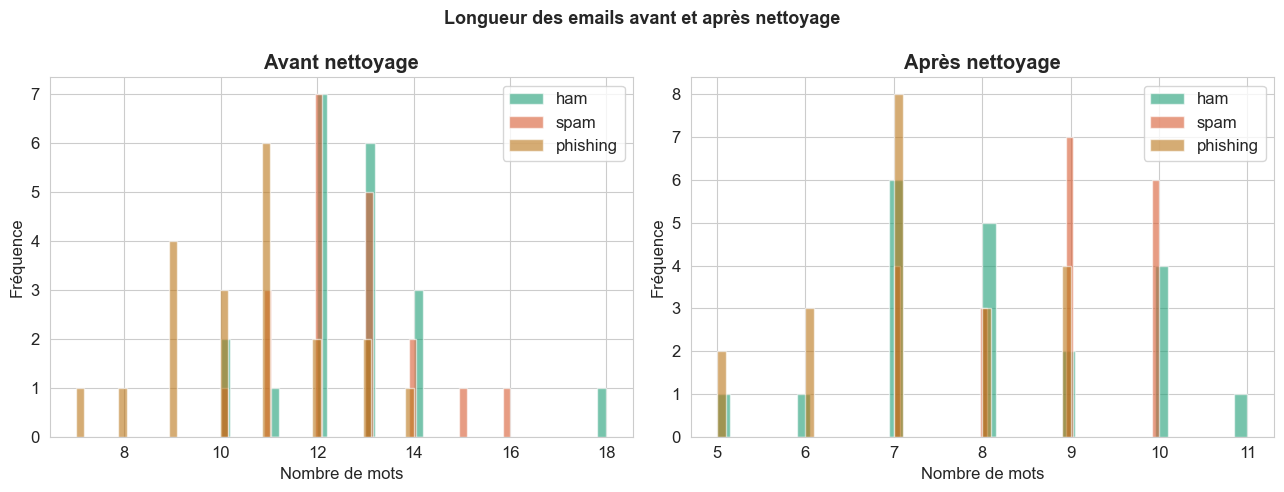

Réduction moyenne du vocabulaire : 32.7%


In [6]:
# Comparaison longueur avant / après nettoyage
df['word_count_clean'] = df['text_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in zip(
    axes,
    ['word_count', 'word_count_clean'],
    ['Avant nettoyage', 'Après nettoyage']
):
    for label in df['label'].unique():
        vals = df[df['label'] == label][col].clip(upper=200)
        ax.hist(vals, bins=40, alpha=0.6, label=label, color=CLASS_COLORS.get(label, 'gray'))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Nombre de mots')
    ax.set_ylabel('Fréquence')
    ax.legend()

plt.suptitle('Longueur des emails avant et après nettoyage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/02_cleaning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

reduction = (1 - df['word_count_clean'].mean() / df['word_count'].mean()) * 100
print(f'Réduction moyenne du vocabulaire : {reduction:.1f}%')

## 3. Feature Engineering

### 3.1 — Features textuelles (TF-IDF)

TF-IDF (Term Frequency – Inverse Document Frequency) mesure l'importance d'un mot dans un email par rapport à l'ensemble du corpus. Un mot très fréquent dans un email mais rare dans les autres obtient un score élevé — c'est précisément ce qu'on veut pour discriminer spam/phishing/ham.

In [7]:
# Paramètres TF-IDF
TFIDF_PARAMS = {
    'max_features': 10_000,    # Vocabulaire limité aux 10 000 termes les plus informatifs
    'ngram_range':  (1, 2),    # Unigrammes ET bigrammes (ex: "account suspended")
    'min_df':       2,         # Ignore les termes apparaissant dans < 2 documents
    'max_df':       0.95,      # Ignore les termes dans > 95% des documents (trop communs)
    'sublinear_tf': True,      # log(tf) au lieu de tf brut — réduit l'effet des mots très fréquents
    'strip_accents': 'unicode',
    'analyzer':     'word',
}

print('Entraînement du vectoriseur TF-IDF...')
tfidf = TfidfVectorizer(**TFIDF_PARAMS)
X_tfidf = tfidf.fit_transform(df['text_clean'])

print(f'Matrice TF-IDF : {X_tfidf.shape[0]:,} emails × {X_tfidf.shape[1]:,} features')
print(f'Densité : {X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]) * 100:.2f}% non-nuls')

# Sauvegarde du vectoriseur
joblib.dump(tfidf, DATA_DIR / 'tfidf_vectorizer.pkl')
print('Vectoriseur sauvegardé : data/tfidf_vectorizer.pkl')

Entraînement du vectoriseur TF-IDF...
Matrice TF-IDF : 60 emails × 74 features
Densité : 5.34% non-nuls
Vectoriseur sauvegardé : data/tfidf_vectorizer.pkl


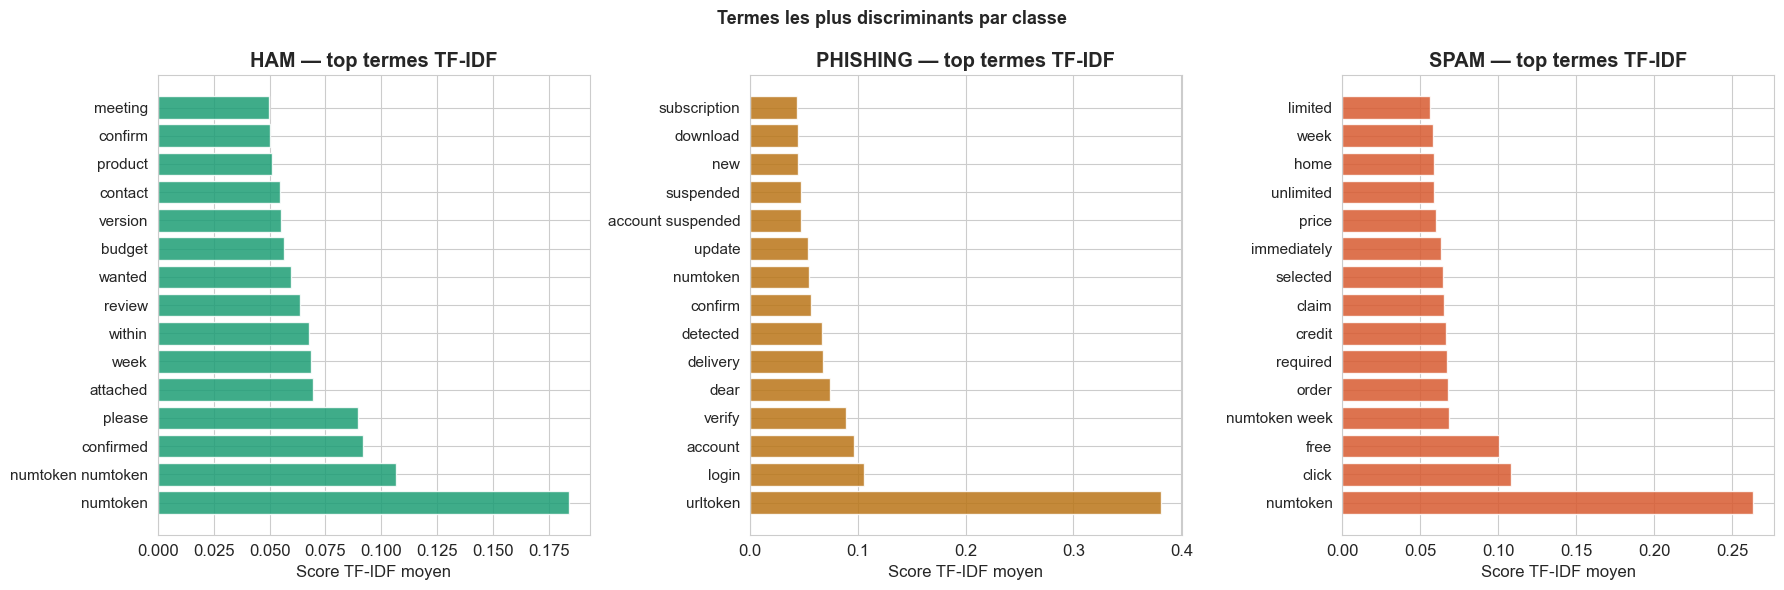

In [8]:
# Top 15 termes TF-IDF par classe
# On calcule le score TF-IDF moyen par terme pour chaque classe

feature_names = np.array(tfidf.get_feature_names_out())
label_encoder_viz = LabelEncoder()
y_encoded = label_encoder_viz.fit_transform(df['label'])

fig, axes = plt.subplots(1, len(label_encoder_viz.classes_),
                          figsize=(6 * len(label_encoder_viz.classes_), 6))
if len(label_encoder_viz.classes_) == 1:
    axes = [axes]

for ax, (label, class_idx) in zip(axes, enumerate(label_encoder_viz.classes_)):
    mask  = (y_encoded == label)
    # Score moyen TF-IDF pour la classe
    mean_tfidf = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
    top_idx    = mean_tfidf.argsort()[-15:][::-1]
    top_terms  = feature_names[top_idx]
    top_scores = mean_tfidf[top_idx]

    color = CLASS_COLORS.get(class_idx, '#888')
    ax.barh(range(15), top_scores[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(15))
    ax.set_yticklabels(top_terms[::-1], fontsize=11)
    ax.set_title(f'{class_idx.upper()} — top termes TF-IDF', fontweight='bold')
    ax.set_xlabel('Score TF-IDF moyen')
    ax.invert_yaxis()

plt.suptitle('Termes les plus discriminants par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/02_top_tfidf_terms.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 — Features structurelles

Au-delà du texte, les emails de phishing et de spam partagent des caractéristiques structurelles détectables :
- **URLs suspectes** : domaines exotiques, adresses IP brutes, sous-domaines trompeurs
- **En-têtes** : incohérences SPF/DKIM, domaine expéditeur ≠ domaine Reply-To
- **Mise en forme** : abus de majuscules, signes `$`, `!`

In [9]:
# Liste de TLDs suspects fréquents dans le phishing (non exhaustive)
SUSPICIOUS_TLDS = {
    'xyz', 'info', 'biz', 'club', 'online', 'site', 'top',
    'win', 'gq', 'tk', 'ml', 'ga', 'cf', 'pw', 'cc', 'ws',
    'icu', 'live', 'click', 'link', 'loan', 'work', 'men'
}

# Domaines légitimes usurpés fréquemment
IMPERSONATED_BRANDS = [
    'paypal', 'amazon', 'microsoft', 'apple', 'google',
    'netflix', 'facebook', 'dhl', 'fedex', 'ups', 'irs',
    'bank', 'secure', 'login', 'verify', 'account', 'update'
]


def extract_url_features(text: str) -> dict:
    """
    Extrait des features basées sur les URLs présentes dans le texte.
    Ces features sont particulièrement discriminantes pour le phishing.
    """
    urls = re.findall(r'https?://[^\s<>"]+', text)

    if not urls:
        return {
            'url_count':            0,
            'has_ip_url':           0,
            'has_suspicious_tld':   0,
            'has_brand_in_url':     0,
            'url_max_length':       0,
            'url_avg_length':       0.0,
            'url_subdomain_count':  0,
            'has_at_in_url':        0,
            'url_digit_ratio':      0.0,
            'url_special_char':     0,
        }

    parsed = []
    for url in urls:
        try:
            parsed.append(urlparse(url))
        except Exception:
            pass

    hostnames = [p.netloc.lower() for p in parsed if p.netloc]
    url_lengths = [len(u) for u in urls]

    # URL avec adresse IP brute (ex: http://192.168.1.1/login)
    has_ip = any(
        bool(re.match(r'^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', h))
        for h in hostnames
    )

    # TLD suspect
    has_susp_tld = any(
        h.rsplit('.', 1)[-1] in SUSPICIOUS_TLDS
        for h in hostnames if '.' in h
    )

    # Marque connue usurpée dans l'URL (ex: paypa1.com, amazon-secure.xyz)
    has_brand = any(
        brand in h
        for h in hostnames
        for brand in IMPERSONATED_BRANDS
    )

    # Nombre moyen de sous-domaines (phishing : souvent beaucoup)
    subdomain_counts = [len(h.split('.')) - 2 for h in hostnames if '.' in h]
    avg_subdomain = np.mean(subdomain_counts) if subdomain_counts else 0

    # @ dans l'URL (technique d'obfuscation : http://legitime.com@malveillant.com)
    has_at = any('@' in u for u in urls)

    # Ratio de chiffres dans les hostnames (IP déguisées, noms aléatoires)
    all_host_chars = ''.join(hostnames)
    digit_ratio = sum(c.isdigit() for c in all_host_chars) / max(len(all_host_chars), 1)

    # Caractères spéciaux dans l'URL (hors ://.)
    special_count = sum(
        len(re.findall(r'[%@#!$&*]', u)) for u in urls
    )

    return {
        'url_count':           len(urls),
        'has_ip_url':          int(has_ip),
        'has_suspicious_tld':  int(has_susp_tld),
        'has_brand_in_url':    int(has_brand),
        'url_max_length':      max(url_lengths),
        'url_avg_length':      float(np.mean(url_lengths)),
        'url_subdomain_count': float(avg_subdomain),
        'has_at_in_url':       int(has_at),
        'url_digit_ratio':     float(digit_ratio),
        'url_special_char':    special_count,
    }


def extract_text_style_features(text: str) -> dict:
    """
    Extrait des features stylistiques liées aux techniques de spam/phishing.
    """
    if not isinstance(text, str) or len(text) == 0:
        return {
            'char_count': 0, 'word_count': 0, 'exclamation_count': 0,
            'question_count': 0, 'dollar_count': 0, 'uppercase_ratio': 0.0,
            'digit_ratio': 0.0, 'has_html': 0, 'avg_word_length': 0.0,
            'unique_word_ratio': 0.0,
        }

    words = text.split()
    alpha_chars = [c for c in text if c.isalpha()]

    return {
        'char_count':        len(text),
        'word_count':        len(words),
        'exclamation_count': text.count('!'),
        'question_count':    text.count('?'),
        'dollar_count':      text.count('$'),
        'uppercase_ratio':   sum(1 for c in alpha_chars if c.isupper()) / max(len(alpha_chars), 1),
        'digit_ratio':       sum(c.isdigit() for c in text) / max(len(text), 1),
        'has_html':          int(bool(re.search(r'<[a-zA-Z][^>]*>', text))),
        'avg_word_length':   float(np.mean([len(w) for w in words])) if words else 0.0,
        'unique_word_ratio': len(set(words)) / max(len(words), 1),
    }


# Application sur tout le dataset
print('Extraction des features URL...')
tqdm.pandas(desc='URL features')
url_feats = df['text'].progress_apply(extract_url_features)
df_url = pd.DataFrame(url_feats.tolist())

print('Extraction des features stylistiques...')
tqdm.pandas(desc='Style features')
style_feats = df['text'].progress_apply(extract_text_style_features)
df_style = pd.DataFrame(style_feats.tolist())

print(f'Features URL    : {len(df_url.columns)}')
print(f'Features style  : {len(df_style.columns)}')

Extraction des features URL...


URL features: 100%|█████████████████████████████████████████████████████████████████| 60/60 [00:00<00:00, 14660.27it/s]


Extraction des features stylistiques...


Style features: 100%|███████████████████████████████████████████████████████████████| 60/60 [00:00<00:00, 12537.78it/s]

Features URL    : 10
Features style  : 10


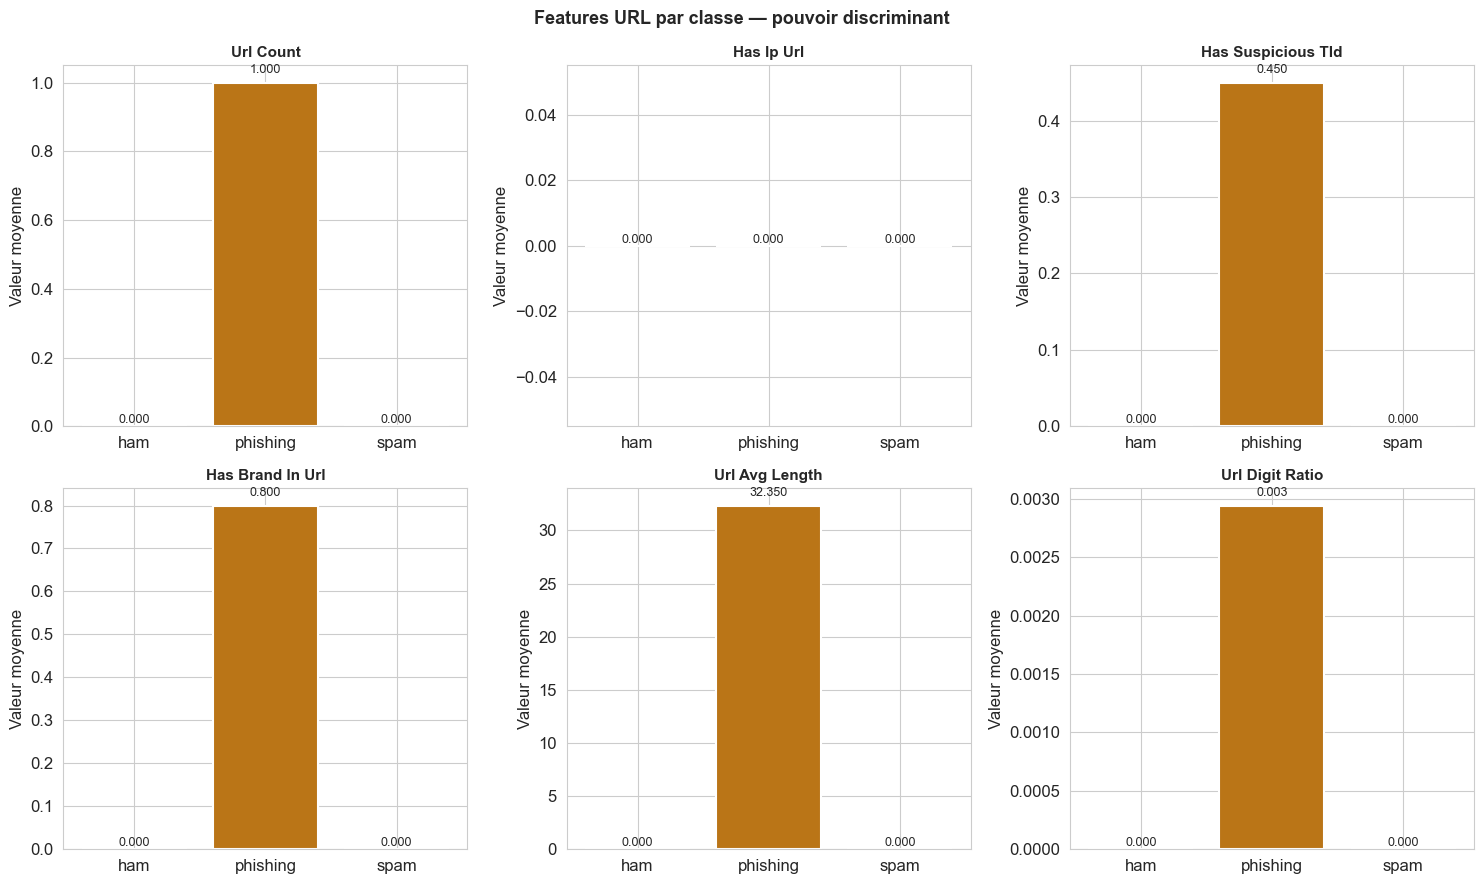

In [10]:
# Visualisation : features URL par classe
df_viz = pd.concat([df[['label']], df_url], axis=1)

url_feat_cols = ['url_count', 'has_ip_url', 'has_suspicious_tld',
                 'has_brand_in_url', 'url_avg_length', 'url_digit_ratio']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, url_feat_cols):
    grouped = df_viz.groupby('label')[col].mean()
    colors  = [CLASS_COLORS.get(l, 'gray') for l in grouped.index]
    bars = ax.bar(grouped.index, grouped.values, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=11)
    ax.set_ylabel('Valeur moyenne')
    for bar, val in zip(bars, grouped.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Features URL par classe — pouvoir discriminant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/02_url_features_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 — Construction de la matrice de features finale

In [12]:
from scipy.sparse import hstack, csr_matrix

# Features structurelles (denses) → on les convertit en sparse pour la concaténation
X_struct = csr_matrix(
    pd.concat([df_url, df_style], axis=1).fillna(0).values
)

# Matrice finale : TF-IDF (10 000 cols) + features structurelles (N cols)
X_all = hstack([X_tfidf, X_struct])

# Encodage des labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])

print(f'Matrice de features finale :')
print(f'  Lignes (emails)     : {X_all.shape[0]:,}')
print(f'  Colonnes (features) : {X_all.shape[1]:,}')
print(f'    dont TF-IDF       : {X_tfidf.shape[1]:,}')
print(f'    dont structurelles: {X_struct.shape[1]:,}')
print(f'  Classes : {dict(zip(label_encoder.classes_, np.bincount(y)))}')

# Sauvegarde du label encoder
joblib.dump(label_encoder, DATA_DIR / 'label_encoder.pkl')
print('Label encoder sauvegardé.')

Matrice de features finale :
  Lignes (emails)     : 60
  Colonnes (features) : 94
    dont TF-IDF       : 74
    dont structurelles: 20
  Classes : {'ham': np.int64(20), 'phishing': np.int64(20), 'spam': np.int64(20)}
Label encoder sauvegardé.


## 4. Gestion du déséquilibre des classes

Le déséquilibre (beaucoup plus de ham/spam que de phishing) est l'un des risques majeurs identifiés au §1.3 du cahier de charges. Deux stratégies complémentaires :

- **SMOTE** (Synthetic Minority Oversampling TEchnique) : génère de nouveaux exemples synthétiques pour la classe minoritaire en interpolant entre exemples existants
- **class_weight** : pénalise davantage les erreurs sur la classe minoritaire lors de l'entraînement (utilisé dans NB 03)

In [13]:
# ---- 4.1 Séparation train/test AVANT le SMOTE ----
# IMPORTANT : le SMOTE ne doit jamais être appliqué sur les données de test.
# Sinon on crée une fuite de données (data leakage).

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_all, y,
    test_size=0.15,
    random_state=42,
    stratify=y          # Maintient les proportions dans chaque split
)

X_train_raw, X_val, y_train_raw, y_val = train_test_split(
    X_train_raw, y_train_raw,
    test_size=0.15,
    random_state=42,
    stratify=y_train_raw
)

print('Répartition avant SMOTE :')
for split_name, y_split in [('Train', y_train_raw), ('Val', y_val), ('Test', y_test)]:
    counts = dict(zip(label_encoder.classes_, np.bincount(y_split, minlength=len(label_encoder.classes_))))
    print(f'  {split_name:5s} ({len(y_split):>6,}) : {counts}')

Répartition avant SMOTE :
  Train (    43) : {'ham': np.int64(15), 'phishing': np.int64(14), 'spam': np.int64(14)}
  Val   (     8) : {'ham': np.int64(2), 'phishing': np.int64(3), 'spam': np.int64(3)}
  Test  (     9) : {'ham': np.int64(3), 'phishing': np.int64(3), 'spam': np.int64(3)}


In [14]:
# ---- 4.2 Application du SMOTE sur le set d'entraînement uniquement ----

# k_neighbors doit être < nombre d'exemples de la classe minoritaire
min_class_count = np.bincount(y_train_raw).min()
k_neighbors     = min(5, min_class_count - 1)
k_neighbors     = max(k_neighbors, 1)

print(f'Classe minoritaire dans le train : {min_class_count} exemples')
print(f'k_neighbors SMOTE : {k_neighbors}')

if min_class_count >= 2:
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)
    print(f'\nAprès SMOTE :')
    counts_after = dict(zip(label_encoder.classes_, np.bincount(y_train)))
    print(f'  Train ({len(y_train):,}) : {counts_after}')
    print(f'  Exemples synthétiques générés : {len(y_train) - len(y_train_raw):,}')
else:
    print('Classe minoritaire trop petite pour SMOTE. Utilisation sans rééchantillonnage.')
    X_train, y_train = X_train_raw, y_train_raw

Classe minoritaire dans le train : 14 exemples
k_neighbors SMOTE : 5

Après SMOTE :
  Train (45) : {'ham': np.int64(15), 'phishing': np.int64(15), 'spam': np.int64(15)}
  Exemples synthétiques générés : 2


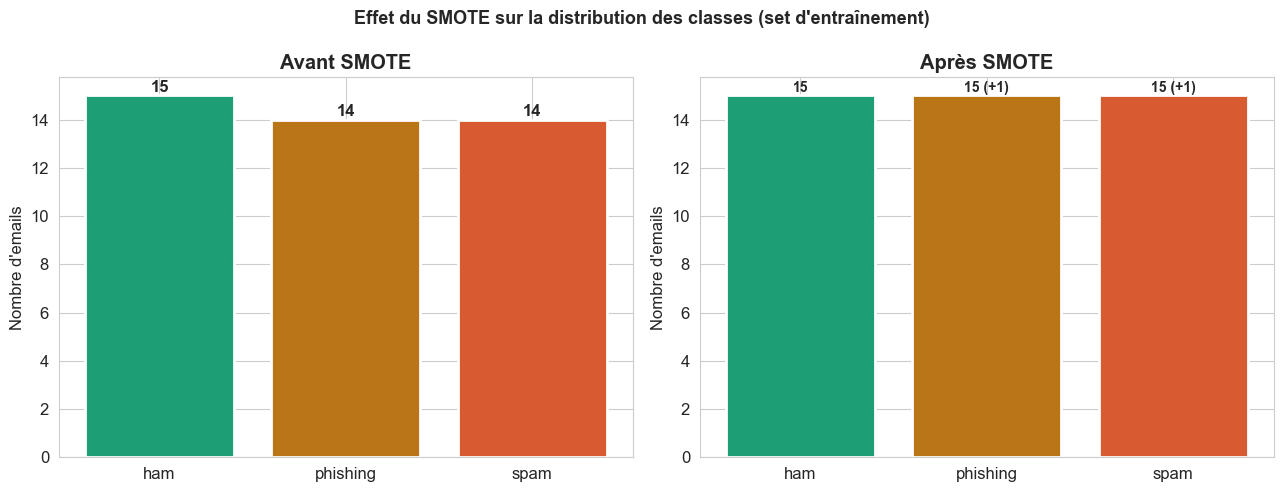

In [15]:
# ---- 4.3 Visualisation de l'effet du SMOTE ----

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels_list = label_encoder.classes_
colors_list = [CLASS_COLORS.get(l, 'gray') for l in labels_list]

# Avant
counts_before = np.bincount(y_train_raw, minlength=len(labels_list))
axes[0].bar(labels_list, counts_before, color=colors_list, edgecolor='white', linewidth=2)
axes[0].set_title('Avant SMOTE', fontweight='bold')
axes[0].set_ylabel('Nombre d\'emails')
for i, v in enumerate(counts_before):
    axes[0].text(i, v + max(counts_before)*0.01, f'{v:,}', ha='center', fontweight='bold')

# Après
counts_after_arr = np.bincount(y_train, minlength=len(labels_list))
bars = axes[1].bar(labels_list, counts_after_arr, color=colors_list, edgecolor='white', linewidth=2)
axes[1].set_title('Après SMOTE', fontweight='bold')
axes[1].set_ylabel('Nombre d\'emails')
for i, (v, v_before) in enumerate(zip(counts_after_arr, counts_before)):
    added = v - v_before
    label_txt = f'{v:,}' + (f' (+{added:,})' if added > 0 else '')
    axes[1].text(i, v + max(counts_after_arr)*0.01, label_txt, ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Effet du SMOTE sur la distribution des classes (set d\'entraînement)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/02_smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()

Réduction de dimension (SVD 2D) pour visualisation...


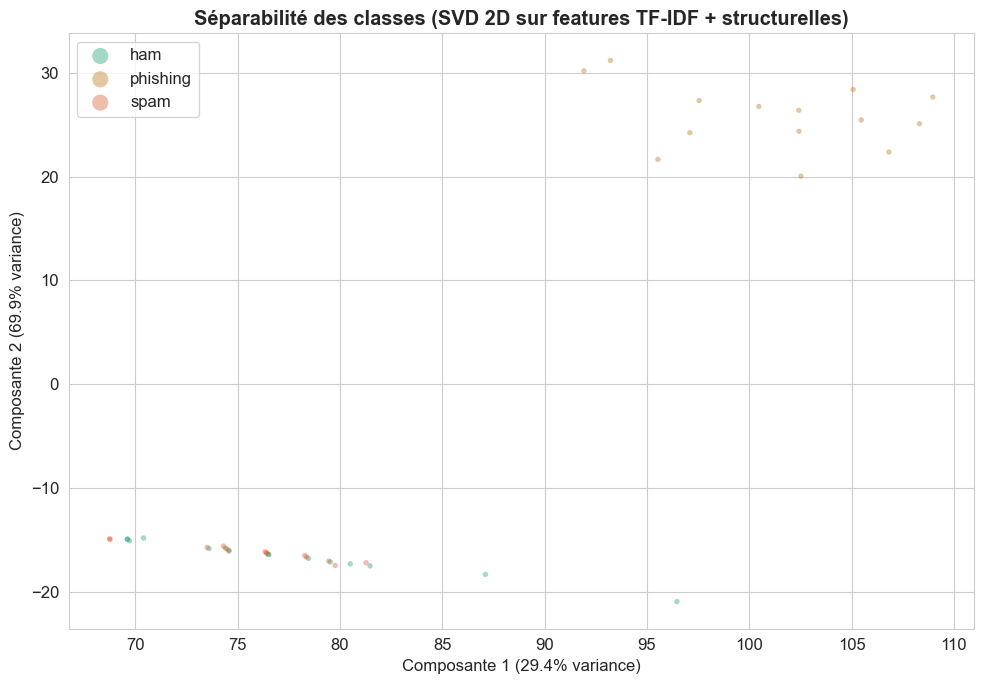

Variance expliquée par les 2 composantes : 99.2%
Si les clusters sont visuellement séparables → bonne séparabilité des classes.


In [16]:
# ---- 4.4 Visualisation PCA/SVD des features (compréhension de la séparabilité) ----
# Réduction à 2D via SVD tronquée (fonctionne sur matrices sparse)

print('Réduction de dimension (SVD 2D) pour visualisation...')
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_train_raw)   # Sur données non-SMOTE pour la visualisation

fig, ax = plt.subplots(figsize=(10, 7))
for label_idx, label_name in enumerate(label_encoder.classes_):
    mask = y_train_raw == label_idx
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=CLASS_COLORS.get(label_name, 'gray'),
        label=label_name, alpha=0.4, s=15, edgecolors='none'
    )

ax.set_title('Séparabilité des classes (SVD 2D sur features TF-IDF + structurelles)',
             fontweight='bold')
ax.set_xlabel(f'Composante 1 ({svd.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'Composante 2 ({svd.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('data/02_svd_separability.png', dpi=150, bbox_inches='tight')
plt.show()

total_var = svd.explained_variance_ratio_.sum() * 100
print(f'Variance expliquée par les 2 composantes : {total_var:.1f}%')
print('Si les clusters sont visuellement séparables → bonne séparabilité des classes.')

## 5. Calcul des class weights

En complément du SMOTE, les class weights serviront directement dans les modèles sklearn (NB 03) et PyTorch/Keras (NB 04) sans modifier les données.

In [17]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_raw),
    y=y_train_raw
)
class_weights_dict = dict(zip(np.unique(y_train_raw), class_weights_arr))

print('Class weights calculés (basés sur le train original) :')
for class_idx, weight in class_weights_dict.items():
    class_name = label_encoder.classes_[class_idx]
    count = (y_train_raw == class_idx).sum()
    print(f'  {class_name:10s} (n={count:,}) → weight = {weight:.3f}')

print()
print('Interprétation : un poids élevé = le modèle sera davantage pénalisé')
print('s\'il se trompe sur cette classe.')

# Sauvegarde
joblib.dump(class_weights_dict, DATA_DIR / 'class_weights.pkl')
print('\nClass weights sauvegardés : data/class_weights.pkl')

Class weights calculés (basés sur le train original) :
  ham        (n=15) → weight = 0.956
  phishing   (n=14) → weight = 1.024
  spam       (n=14) → weight = 1.024

Interprétation : un poids élevé = le modèle sera davantage pénalisé
s'il se trompe sur cette classe.

Class weights sauvegardés : data/class_weights.pkl


## 6. Sauvegarde de tous les artefacts

In [18]:
import scipy.sparse as sp

# Sauvegarde des splits
sp.save_npz(DATA_DIR / 'X_train.npz', X_train)
sp.save_npz(DATA_DIR / 'X_val.npz',   X_val)
sp.save_npz(DATA_DIR / 'X_test.npz',  X_test)

np.save(DATA_DIR / 'y_train.npy', y_train)
np.save(DATA_DIR / 'y_val.npy',   y_val)
np.save(DATA_DIR / 'y_test.npy',  y_test)

# Sauvegarde du dataframe avec texte nettoyé (utilisé par NB 04 pour BERT)
df_export = df[['text', 'text_clean', 'label', 'source']].copy()
df_export.to_csv(DATA_DIR / 'emails_features.csv', index=False, encoding='utf-8')

# Sauvegarde des noms de features pour interprétabilité (NB 03)
struct_col_names = list(df_url.columns) + list(df_style.columns)
all_feature_names = list(tfidf.get_feature_names_out()) + struct_col_names
joblib.dump(all_feature_names, DATA_DIR / 'feature_names.pkl')

print('Artefacts sauvegardés :')
for f in sorted(DATA_DIR.glob('*')):
    print(f'  {f.name:35s} {f.stat().st_size / 1024:>8.0f} KB')

Artefacts sauvegardés :
  01_class_distribution.png                 74 KB
  01_correlation.png                        98 KB
  01_discriminant_features.png              80 KB
  01_ip_url_presence.png                    37 KB
  01_length_distribution.png                66 KB
  01_wordclouds.png                        938 KB
  02_cleaning_comparison.png                56 KB
  02_smote_effect.png                       43 KB
  02_svd_separability.png                   61 KB
  02_top_tfidf_terms.png                   116 KB
  02_url_features_by_class.png             110 KB
  class_weights.pkl                          0 KB
  emails_features.csv                        9 KB
  emails_raw.csv                             8 KB
  feature_names.pkl                          1 KB
  label_encoder.pkl                          0 KB
  tfidf_vectorizer.pkl                       4 KB
  X_test.npz                                 2 KB
  X_train.npz                                3 KB
  X_val.npz               

## 7. Résumé final du pipeline

In [19]:
print('=' * 65)
print('RÉSUMÉ — Notebook 02 : Prétraitement & Feature Engineering')
print('=' * 65)

print(f'\n  Emails total         : {len(df):,}')
print(f'  Features totales     : {X_all.shape[1]:,}')
print(f'    TF-IDF             : {X_tfidf.shape[1]:,}')
print(f'    Structurelles URL  : {len(df_url.columns)}')
print(f'    Structurelles style: {len(df_style.columns)}')

print(f'\n  Splits :')
print(f'    Train (avec SMOTE) : {X_train.shape[0]:,}')
print(f'    Validation         : {X_val.shape[0]:,}')
print(f'    Test               : {X_test.shape[0]:,}')

print(f'\n  Fichiers produits pour NB 03 & 04 :')
for fname in ['X_train.npz', 'X_val.npz', 'X_test.npz',
              'y_train.npy', 'y_val.npy', 'y_test.npy',
              'tfidf_vectorizer.pkl', 'label_encoder.pkl',
              'class_weights.pkl', 'feature_names.pkl',
              'emails_features.csv']:
    path = DATA_DIR / fname
    exists = '✓' if path.exists() else '✗'
    print(f'    {exists} {fname}')

print()
print('  Prochain : NB 03 — Modèles ML classiques (Naive Bayes, SVM, Random Forest)')

RÉSUMÉ — Notebook 02 : Prétraitement & Feature Engineering

  Emails total         : 60
  Features totales     : 94
    TF-IDF             : 74
    Structurelles URL  : 10
    Structurelles style: 10

  Splits :
    Train (avec SMOTE) : 45
    Validation         : 8
    Test               : 9

  Fichiers produits pour NB 03 & 04 :
    ✓ X_train.npz
    ✓ X_val.npz
    ✓ X_test.npz
    ✓ y_train.npy
    ✓ y_val.npy
    ✓ y_test.npy
    ✓ tfidf_vectorizer.pkl
    ✓ label_encoder.pkl
    ✓ class_weights.pkl
    ✓ feature_names.pkl
    ✓ emails_features.csv

  Prochain : NB 03 — Modèles ML classiques (Naive Bayes, SVM, Random Forest)


## Notes méthodologiques

### Choix justifiés

| Choix | Justification |
|-------|---------------|
| TF-IDF avec bigrammes | Capture les expressions multi-mots comme "account suspended", "click here" |
| Tokens spéciaux (urltoken) | Préserve l'information sémantique sans sur-indexer des URLs spécifiques |
| SMOTE sur train uniquement | Évite le data leakage — le test reflète la réalité du déséquilibre |
| Features URL structurelles | Complémentaires au texte — un phishing peut avoir un contenu banal mais une URL suspecte |
| `sublinear_tf=True` | Réduit l'effet des mots très fréquents, améliore la discrimination |

### Pièges évités (§4 du cahier de charges)
- **Data leakage** : SMOTE appliqué uniquement au train
- **Déséquilibre ignoré** : traité par SMOTE + class_weights sauvegardés
- **Overfitting vocabulaire** : `min_df=2` et `max_df=0.95` filtrent les extrêmes

### Prochain notebook
**NB 03** utilise directement `X_train.npz`, `X_val.npz`, `X_test.npz` et `class_weights.pkl` pour entraîner et comparer Naive Bayes, SVM et Random Forest.